In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
moltean_fruits_path = kagglehub.dataset_download('moltean/fruits')

print('Data source import complete.')

100%|██████████| 3.49G/3.49G [01:28<00:00, 42.3MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

train_dir = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training"
test_dir  = "/kaggle/input/fruits/fruits-360_100x100/fruits-360/Test"

IMG_SIZE = (100, 100)
BATCH_SIZE = 32
EPOCHS = 5



In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical'
)

num_classes = train_gen.num_classes


Found 83631 images belonging to 207 classes.
Found 20825 images belonging to 207 classes.
Found 34864 images belonging to 207 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen, verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 1329s 507ms/step - accuracy: 0.5009 - loss: 2.1288 - val_accuracy: 0.9035 - val_loss: 0.3613
Epoch 2/5
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 1257s 481ms/step - accuracy: 0.9061 - loss: 0.2722 - val_accuracy: 0.9081 - val_loss: 0.4011
Epoch 3/5
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 1234s 472ms/step - accuracy: 0.9364 - loss: 0.1844 - val_accuracy: 0.9290 - val_loss: 0.3197
Epoch 4/5
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 1215s 465ms/step - accuracy: 0.9509 - loss: 0.1417 - val_accuracy: 0.9236 - val_loss: 0.3791
Epoch 5/5
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 1278s 489ms/step - accuracy: 0.9586 - loss: 0.1196 - val_accuracy: 0.9134 - val_loss: 0.4684


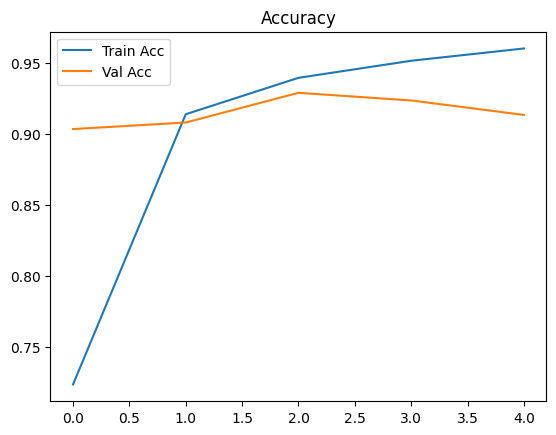

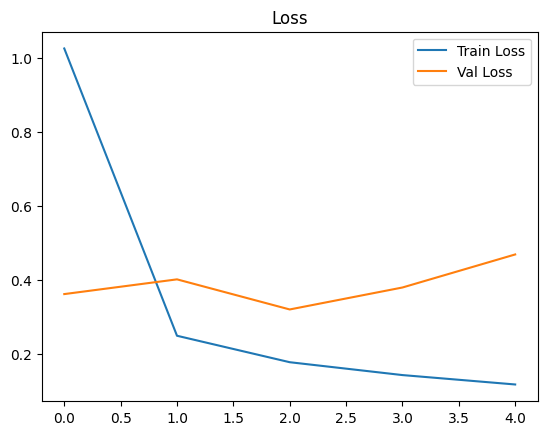

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss"); plt.show()

1090/1090 ━━━━━━━━━━━━━━━━━━━━ 187s 172ms/step - accuracy: 0.9387 - loss: 0.3135
Test Accuracy: 93.98%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
True: Peach Flat 1  | Pred: Cactus fruit 1


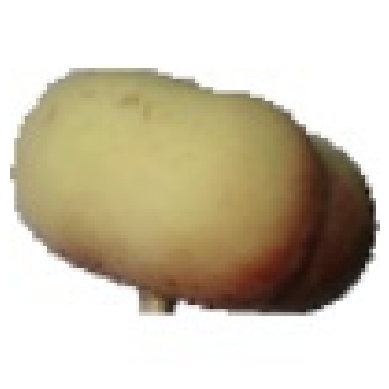

In [ ]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

# Show one prediction
x_batch, y_batch = next(test_gen)
preds = model.predict(x_batch)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_batch, axis=1)

inv_map = {v:k for k,v in train_gen.class_indices.items()}

plt.imshow(x_batch[0])
plt.axis('off')
print("True:", inv_map[true_labels[0]], " | Pred:", inv_map[pred_labels[0]])

In [ ]:
import random

# Show 8 random fruits from test set with predictions
x_batch, y_batch = next(test_gen)   # take one batch of test images
plt.figure(figsize=(15, 8))

for i in range(8):
    ax = plt.subplot(2, 4, i + 1)

    idx = random.randint(0, len(x_batch)-1)  # random index
    image = x_batch[idx]

    # Prediction
    pred = model.predict(image[np.newaxis, ...], verbose=0)
    pred_label = np.argmax(pred)
    true_label = np.argmax(y_batch[idx])

    inv_map = {v:k for k,v in train_gen.class_indices.items()}

    plt.imshow(image)
    plt.title(f"True: {inv_map[true_label]}\nPred: {inv_map[pred_label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'test_gen' is not defined

In [ ]:
model.save("fruit_classifier.h5")
print("Model saved as fruit_classifier.h5")


Model saved as fruit_classifier.h5
